# 第 5 週:從桿件跨到樑元素——Euler-Bernoulli 樑彎曲的四方比對

**課程:計算力學方法論——驗證、確效與跨平台交叉比對**

前四週,所有東西都建立在一維桿件(只有軸向拉伸,每個節點 1 個自由度)上。
這週要做全學期第一次「換題目」的測試:**同一套「手算 + 套件反向驗證 + 獨立方法交叉比對」的框架,
搬到一個結構上不同的問題——樑的彎曲——還走得通嗎?**

這不是簡單的換個數字重跑。樑彎曲會強迫我們面對三個桿件問題完全沒有的新麻煩:

1. 統御方程式從二階變成**四階**
2. 每個節點的自由度從 1 個(位移)變成 **2 個**(撓度 + 轉角)
3. 有限元素的形狀函數不能再用簡單的線性/二次多項式(Lagrange 型),必須換成 **Hermite 型**——
   原因會在推導過程中自然浮現,不是先講結論

這週延續第 1 週的精神,最後會重現「四方比對」的完整結構:解析解、手算 FEM、套件 FEM、
獨立數值方法(這次改用 4 階 ODE 的 SciPy BVP)。

In [1]:
%pip install -q scikit-fem scipy matplotlib numpy sympy

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


## 1. 問題描述:懸臂樑承受均佈荷重

長度 $L$、抗彎剛度 $EI$(暫時仍設為常數,呼應第 1 週從常係數開始的精神)的樑,
左端 $x=0$ 固定(位移與轉角皆為零),右端 $x=L$ 自由,沿全長承受均佈側向荷重 $q$(N/m)。

未知量是撓度 $v(x)$(側向位移),而不是桿件問題的軸向位移 $u(x)$。

## 2. 從樑理論推導統御方程式(四階,不是二階)

樑彎曲的三個基本關係(材料力學課程應該都推過,這裡快速重建,重點在銜接到有限元素部分):

$$M(x) = EI\,v''(x) \qquad\text{(彎矩-曲率關係)}$$
$$\frac{dV}{dx} = -q(x) \qquad\text{(剪力平衡)}$$
$$\frac{dM}{dx} = V(x) \qquad\text{(彎矩平衡)}$$

三式合併,消去 $M,V$:

$$EI\,v''''(x) = q(x)$$

**這是本週第一個關鍵差異**:桿件問題是二階 ODE($-(EAu')'=f$),樑彎曲是**四階** ODE。
邊界條件也對應變多:每一端需要兩個條件,本題(懸臂樑)為

$$v(0)=0,\quad v'(0)=0 \qquad\text{(固定端:位移、轉角皆為零,本質邊界條件)}$$
$$EI\,v''(L)=0,\quad EI\,v'''(L)=0 \qquad\text{(自由端:彎矩、剪力皆為零,自然邊界條件)}$$

## 3. 弱形式推導:為什麼需要「兩次」分部積分,以及為什麼形狀函數不能只是分段多項式

跟第 2 週一樣的套路——乘上測試函數 $w$(滿足 $w(0)=w'(0)=0$),積分,分部積分——
只是這次因為方程式是四階,要做**兩次**分部積分才能把微分階數從 $v''''$ 降到 $v''$:

$$\int_0^L EI\,v''''\,w\,dx = \int_0^L q\,w\,dx$$

第一次分部積分(把一階微分從 $v''''$ 移到 $w$):

$$\Big[EI v''' w\Big]_0^L - \int_0^L EI v''' w'\,dx = \int_0^L qw\,dx$$

第二次分部積分:

$$\Big[EI v''' w\Big]_0^L - \Big[EI v'' w'\Big]_0^L + \int_0^L EI\,v''w''\,dx = \int_0^L qw\,dx$$

邊界項在 $x=0$ 因為 $w(0)=w'(0)=0$ 自動消失;在 $x=L$ 因為自然邊界條件 $EI v''(L)=EI v'''(L)=0$
自動消失。整理得弱形式:

$$\int_0^L EI\,v''(x)\,w''(x)\,dx = \int_0^L q(x)\,w(x)\,dx$$

**這裡有一件桿件問題沒遇過的事,值得停下來想清楚**:弱形式裡出現的是 $v''$(二階導數),
不是 $v'$。桿件的弱形式只需要 $u'$,所以只要求形狀函數在元素邊界**函數值連續**($C^0$)即可
——這正是第 1、3 週用的分段線性/二次 Lagrange 元素的特性。但樑的弱形式需要對 $v''$ 積分,
如果形狀函數只有 $C^0$ 連續(值連續但**導數**在元素邊界不連續),$v''$ 在元素邊界會出現
狄拉克函數式的奇異點,弱形式的積分沒有意義。

**結論:樑元素需要 $C^1$ 連續的形狀函數——不只函數值,連一階導數(轉角)在元素邊界也要連續。**
這正是為什麼每個節點需要兩個自由度(撓度 $v$、轉角 $\theta=v'$),也是為什麼形狀函數必須換成
**Hermite 型**(用函數值與導數共同定義形狀函數),而不能再用只看函數值的 Lagrange 型。

## 4. 推導 Hermite 三次形狀函數(親手推導,不是查表抄公式)

一個二節點樑元素,局部座標 $s\in[0,L_e]$($L_e$ 為元素長度),4 個自由度依序為
$v_1,\theta_1,v_2,\theta_2$(節點 1 的撓度、轉角,節點 2 的撓度、轉角)。
每個形狀函數 $N_i(s)$ 都是三次多項式,由「在兩端點的函數值與導數值」這 4 個條件唯一決定。

例如 $N_1(s)$ 對應 $v_1$ 這個自由度,定義為:$N_1(0)=1,\ N_1'(0)=0,\ N_1(L_e)=0,\ N_1'(L_e)=0$
(意思是「只有 $v_1=1$、其餘三個自由度都是 0」時,樑的撓度形狀長什麼樣子)。
用 `sympy` 解這個線性方程組,四個形狀函數一次全部推出來:

In [2]:
import sympy as sp

s, Le = sp.symbols('s Le', positive=True)
a0, a1, a2, a3 = sp.symbols('a0 a1 a2 a3')
poly = a0 + a1*s + a2*s**2 + a3*s**3
dpoly = sp.diff(poly, s)

def solve_hermite(vals):
    # vals = [value at s=0, derivative at s=0, value at s=Le, derivative at s=Le]
    eqs = [sp.Eq(poly.subs(s, 0), vals[0]),
           sp.Eq(dpoly.subs(s, 0), vals[1]),
           sp.Eq(poly.subs(s, Le), vals[2]),
           sp.Eq(dpoly.subs(s, Le), vals[3])]
    coeffs = sp.solve(eqs, [a0, a1, a2, a3])
    return sp.expand(poly.subs(coeffs))

N1 = solve_hermite([1, 0, 0, 0])   # 對應 v1
N2 = solve_hermite([0, 1, 0, 0])   # 對應 theta1
N3 = solve_hermite([0, 0, 1, 0])   # 對應 v2
N4 = solve_hermite([0, 0, 0, 1])   # 對應 theta2

for name, Ni in zip(['N1 (v1)', 'N2 (theta1)', 'N3 (v2)', 'N4 (theta2)'], [N1, N2, N3, N4]):
    print(f"{name}: {Ni}")

N1 (v1): 1 - 3*s**2/Le**2 + 2*s**3/Le**3
N2 (theta1): s - 2*s**2/Le + s**3/Le**2
N3 (v2): 3*s**2/Le**2 - 2*s**3/Le**3
N4 (theta2): -s**2/Le + s**3/Le**2


你應該會認出這組式子就是材料力學課本裡的「三次 Hermite 內插函數」——差別是這裡不是抄公式,
是從「4 個自由度、4 個邊界條件、唯一決定一個三次多項式」這個邏輯直接解出來的。

弱形式需要 $N_i''$(彎矩-曲率關係用得到),一併求出來:

In [3]:
N = [N1, N2, N3, N4]
Npp = [sp.diff(Ni, s, 2) for Ni in N]
for name, Nppi in zip(['N1', 'N2', 'N3', 'N4'], Npp):
    print(f"{name}'' = {Nppi}")

N_funcs = [sp.lambdify((s, Le), Ni, 'numpy') for Ni in N]
Npp_funcs = [sp.lambdify((s, Le), Ni, 'numpy') for Ni in Npp]

N1'' = 6*(-1 + 2*s/Le)/Le**2
N2'' = 2*(-2 + 3*s/Le)/Le
N3'' = 6*(1 - 2*s/Le)/Le**2
N4'' = 2*(-1 + 3*s/Le)/Le


## 5. 手算元素矩陣組裝與求解

跟前四週同樣的邏輯:元素勁度矩陣 $K_e = \int_0^{L_e} EI\,N_i''N_j''\,ds$,
等效節點荷重 $F_e=\int_0^{L_e} q\,N_i\,ds$,用高斯積分算(被積函數是多項式,2 點高斯積分足夠精確)。
組裝方式與桿件相同,只是現在每個節點佔 2 個全域自由度(撓度、轉角交錯排列)。

In [4]:
import numpy as np

L_val, EI_val, q_val = 1.0, 1000.0, 10.0
gauss_pts = [-1/np.sqrt(3), 1/np.sqrt(3)]
gauss_wts = [1.0, 1.0]

def assemble_solve_beam_hand(n_elements):
    n_nodes = n_elements + 1
    coords = np.linspace(0, L_val, n_nodes)
    ndof = 2 * n_nodes
    K = np.zeros((ndof, ndof))
    F = np.zeros(ndof)

    for e in range(n_elements):
        x1, x2 = coords[e], coords[e + 1]
        Le_val = x2 - x1
        Ke = np.zeros((4, 4))
        Fe = np.zeros(4)
        for xi, w in zip(gauss_pts, gauss_wts):
            s_phys = (xi + 1) / 2 * Le_val
            J = Le_val / 2
            Nv = np.array([f(s_phys, Le_val) for f in N_funcs])
            Npp_v = np.array([f(s_phys, Le_val) for f in Npp_funcs])
            Ke += EI_val * np.outer(Npp_v, Npp_v) * J * w
            Fe += q_val * Nv * J * w
        gidx = [2*e, 2*e+1, 2*e+2, 2*e+3]   # [v_left, theta_left, v_right, theta_right]
        for i, gi in enumerate(gidx):
            F[gi] += Fe[i]
            for j, gj in enumerate(gidx):
                K[gi, gj] += Ke[i, j]

    # 邊界條件:固定端 v(0)=0, theta(0)=0 -> 全域自由度 0,1
    for d in [0, 1]:
        K[d, :] = 0.0; K[:, d] = 0.0; K[d, d] = 1.0; F[d] = 0.0

    u = np.linalg.solve(K, F)
    return coords, u   # u 交錯排列: [v0,theta0,v1,theta1,...]

coords_hand, u_hand = assemble_solve_beam_hand(4)
v_hand = u_hand[0::2]
theta_hand = u_hand[1::2]
print("手算 FEM 節點撓度:", np.round(v_hand, 8))
print("手算 FEM 節點轉角:", np.round(theta_hand, 8))

手算 FEM 節點撓度: [0.         0.00013184 0.00044271 0.00083496 0.00125   ]
手算 FEM 節點轉角: [0.         0.00096354 0.00145833 0.00164062 0.00166667]


## 6. 解析解與第一次比對

懸臂樑均佈荷重的經典封閉解(可由第 2 節統御方程式直接積分四次、代入邊界條件得到,
過程與第 2 週桿件問題的積分完全同構,這裡不重複推導細節):

$$v(x) = \frac{q}{24EI}\left(x^4 - 4Lx^3 + 6L^2x^2\right), \qquad v(L) = \frac{qL^4}{8EI}$$

In [5]:
def v_exact(xx):
    return q_val / (24*EI_val) * (xx**4 - 4*L_val*xx**3 + 6*L_val**2*xx**2)

v_exact_nodes = v_exact(coords_hand)
print("解析解節點撓度:", np.round(v_exact_nodes, 8))
print("手算 FEM 最大節點誤差:", np.max(np.abs(v_hand - v_exact_nodes)))
print("\n懸臂樑尖端撓度: 手算 =", v_hand[-1], " 解析解 =", v_exact(L_val),
      " (理論公式 qL⁴/8EI =", q_val*L_val**4/(8*EI_val), ")")

解析解節點撓度: [0.         0.00013184 0.00044271 0.00083496 0.00125   ]
手算 FEM 最大節點誤差: 3.165870343657673e-17

懸臂樑尖端撓度: 手算 = 0.0012499999999999684  解析解 = 0.00125  (理論公式 qL⁴/8EI = 0.00125 )


**跟第 1 週一模一樣的現象又出現了**:誤差是機器精度量級,不是「夠接近」。原因也跟第 1、2 週
討論過的「節點精確性」同源——本題 $EI$ 為常數、荷重為常數,解析解剛好是四次多項式,
雖然 Hermite 三次元素在元素內部無法精確表達四次曲線的曲率變化,但節點處的撓度與轉角
仍然精確吻合解析解。**這不是巧合,是同一族「常係數 + 多項式荷重 → 節點精確」現象在樑元素上的版本**
——也再次提醒我們:第 6 週要引入的非均勻剛度或非線性,會讓這個「太漂亮」的結果消失,
才是更貼近實務的情形。

## 7. 反向驗證:套件 scikit-fem 的 Hermite 元素

scikit-fem 內建 `ElementLineHermite`,DiscreteField 提供 `.hess`(二階導數),
剛好對應弱形式裡的 $v''$。跟第 1、3 週同樣的邏輯:理論相同、實作不同,結果應該一致。

有兩個實務細節要注意(也是套件的「隱藏假設」,呼應第 4 週的精神):
- Hermite 元素每個節點有 2 個自由度,`basis.nodal_dofs[0]` 是撓度自由度、`[1]` 是轉角自由度
  的全域索引——不會自動幫你分好,要自己查
- 固定端邊界條件要同時作用在撓度與轉角兩個自由度上,用 `basis.get_dofs` 依座標篩選

In [6]:
from skfem import MeshLine, ElementLineHermite, Basis, BilinearForm, LinearForm, solve, condense

def skfem_beam(n_elements):
    mesh = MeshLine(np.linspace(0, L_val, n_elements + 1))
    basis = Basis(mesh, ElementLineHermite())

    @BilinearForm
    def a_form(u, v, w):
        return EI_val * u.hess[0, 0] * v.hess[0, 0]

    @LinearForm
    def L_form(v, w):
        return q_val * v

    A_mat = a_form.assemble(basis)
    b_vec = L_form.assemble(basis)
    dofs_fixed = basis.get_dofs(lambda x: x[0] == 0.0)   # 撓度+轉角自由度都在 x=0 被固定
    u = solve(*condense(A_mat, b_vec, D=dofs_fixed))
    return mesh, basis, u

mesh_sk, basis_sk, u_sk = skfem_beam(4)
value_dofs = basis_sk.nodal_dofs[0]
coords_sk = mesh_sk.p[0]
order = np.argsort(coords_sk)
v_sk = u_sk[value_dofs][order]
coords_sk_sorted = coords_sk[order]

print("scikit-fem 節點撓度:", np.round(v_sk, 8))
print("手算 vs scikit-fem 最大差異:", np.max(np.abs(v_sk - v_hand)))

scikit-fem 節點撓度: [0.         0.00013184 0.00044271 0.00083496 0.00125   ]
手算 vs scikit-fem 最大差異: 5.074066167232161e-17


## 8. 獨立驗證途徑:SciPy BVP,四階 ODE 降階為 4 個一階方程

跟第 1 週的邏輯完全對應——不透過任何有限元素或弱形式理論,直接對強形式的四階 ODE 數值求解。
令 $y_1=v,\ y_2=v',\ y_3=v'',\ y_4=v'''$:

$$y_1'=y_2,\quad y_2'=y_3,\quad y_3'=y_4,\quad y_4' = q/EI$$

邊界條件:$y_1(0)=0,\ y_2(0)=0$(固定端);$y_3(L)=0,\ y_4(L)=0$(自由端,彎矩、剪力為零)。

In [7]:
from scipy.integrate import solve_bvp

def ode_system(xx, y):
    return np.vstack((y[1], y[2], y[3], np.full_like(xx, q_val / EI_val)))

def boundary_conditions(ya, yb):
    return np.array([ya[0], ya[1], yb[2], yb[3]])

x_mesh = coords_hand  # 用跟手算/套件相同的節點位置方便比較
y_guess = np.zeros((4, x_mesh.size))
sol_bvp = solve_bvp(ode_system, boundary_conditions, x_mesh, y_guess, tol=1e-10, max_nodes=100000)
print(sol_bvp.status, sol_bvp.message)

v_scipy = sol_bvp.sol(coords_hand)[0]
print("SciPy BVP 節點撓度:", np.round(v_scipy, 8))

0 The algorithm converged to the desired accuracy.
SciPy BVP 節點撓度: [-0.          0.00013184  0.00044271  0.00083496  0.00125   ]


## 9. 四方比對總表與繪圖

In [8]:
print("=== 懸臂樑撓度:四方比對 (m) ===")
print(f"{'x':>8}{'解析解':>14}{'手算FEM':>14}{'scikit-fem':>14}{'SciPy BVP':>14}")
for i, xc in enumerate(coords_hand):
    print(f"{xc:8.3f}{v_exact_nodes[i]:14.8f}{v_hand[i]:14.8f}{v_sk[i]:14.8f}{v_scipy[i]:14.8f}")

print("\n=== 最大節點誤差(相對解析解)===")
print(f"手算 FEM   : {np.max(np.abs(v_hand - v_exact_nodes)):.3e}")
print(f"scikit-fem : {np.max(np.abs(v_sk - v_exact_nodes)):.3e}")
print(f"SciPy BVP  : {np.max(np.abs(v_scipy - v_exact_nodes)):.3e}")

=== 懸臂樑撓度:四方比對 (m) ===
       x           解析解         手算FEM    scikit-fem     SciPy BVP
   0.000    0.00000000    0.00000000    0.00000000   -0.00000000
   0.250    0.00013184    0.00013184    0.00013184    0.00013184
   0.500    0.00044271    0.00044271    0.00044271    0.00044271
   0.750    0.00083496    0.00083496    0.00083496    0.00083496
   1.000    0.00125000    0.00125000    0.00125000    0.00125000

=== 最大節點誤差(相對解析解)===
手算 FEM   : 3.166e-17
scikit-fem : 1.908e-17
SciPy BVP  : 4.337e-19


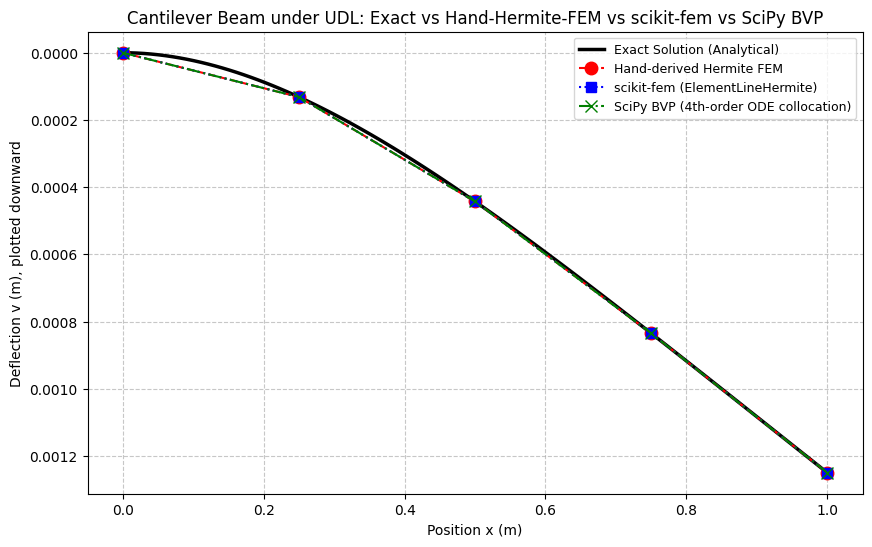

In [9]:
import matplotlib.pyplot as plt

x_fine = np.linspace(0, L_val, 100)
plt.figure(figsize=(10, 6))
plt.plot(x_fine, v_exact(x_fine), 'k-', linewidth=2.5, label='Exact Solution (Analytical)')
plt.plot(coords_hand, v_hand, 'ro--', markersize=9, label='Hand-derived Hermite FEM')
plt.plot(coords_sk_sorted, v_sk, 'bs:', markersize=7, label='scikit-fem (ElementLineHermite)')
plt.plot(coords_hand, v_scipy, 'gx-.', markersize=8, label='SciPy BVP (4th-order ODE collocation)')
plt.gca().invert_yaxis()  # 撓度習慣往下畫成正方向
plt.title("Cantilever Beam under UDL: Exact vs Hand-Hermite-FEM vs scikit-fem vs SciPy BVP")
plt.xlabel("Position x (m)")
plt.ylabel("Deflection v (m), plotted downward")
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 10. 討論:樑元素比桿件「貴」在哪裡,不只是自由度變多

回顧這週跟第 1 週的結構性差異,重點不是「數字變多了」,是**質變**:

- 自由度數量:桿件每節點 1 個,樑每節點 2 個——這只是量的差異,不難處理
- **連續性要求從 $C^0$ 升級到 $C^1$**——這是質的差異。$C^0$ 元素(Lagrange 型)只要求函數值
  在元素邊界連續,樑元素還要求斜率也連續,這直接決定了必須換一整族新的形狀函數(Hermite 型),
  不是加減幾個自由度就能解決的事
- 這個 $C^1$ 要求,根源在弱形式裡出現了 $v''$(二階導數)——而這又根源自統御方程式本身是四階
  ($v''''$)。**弱形式需要的最高導數階數,直接決定了形狀函數需要的連續性等級**,這是一個
  一般性的原則,不只適用於樑:未來遇到任何新的統御方程式,先看弱形式裡最高階導數是幾階,
  就能推斷需要哪一種連續性的元素

第 12 週會再遇到這個原則一次(客製化元素開發),到時候會更有感覺。

## 11. 討論題(課堂/作業)

1. 試著把懸臂樑的邊界條件從「固定-自由」改成「簡支樑」(兩端 $v=0$,但兩端轉角不為零,
   即兩端 $M=0$ 而非 $\theta=0$)。這屬於本質邊界條件還是自然邊界條件?動手修改本週的手算程式碼,
   驗證新邊界條件下的解與材料力學課本的簡支樑均佈荷重公式是否一致。
2. 把荷重從均佈 $q$ 改成懸臂樑尖端集中力 $P$(即 $q(x)=0$,但在 $x=L$ 額外施加剪力邊界條件
   $EI v'''(L) = -P$,或等價地在有限元素等效節點力向量的最後一個節點直接加上 $P$)。
   驗證尖端撓度是否符合經典公式 $PL^3/(3EI)$。
3. 第 6 節看到樑元素在常係數、常荷重下也有節點精確性。試著把 $EI$ 換成沿長度線性變化的
   $EI(x)=EI_0(1+x/L)$(結構上像第 2 週把 $EA$ 推廣成 $EA(x)$ 的操作),重跑手算與 scikit-fem,
   確認節點精確性是否如預期消失、兩者是否仍然互相吻合。
4. 本週的 SciPy BVP 呼叫直接把 `x_mesh` 設成跟手算/套件一樣的節點位置,只是為了方便比較表格,
   並不是 `solve_bvp` 求解時真正使用的網格(它會自動加密)。查看 `sol_bvp.x` 印出來,
   它實際用了幾個內部網格點?這跟第 4 週「漸近前區間」的網格加密邏輯有沒有相似之處?

## 下週預告

第 6 週要在這根彈性樑上引入非線性:集中塑性鉸模型。樑的彈性部分(本週建立的 Hermite 元素)
保持不變,額外在特定位置(例如固定端)插入一個「零長度」的非線性轉動彈簧,模擬材料降伏後的
塑性轉動能力。這是全學期第一次真正的非線性問題,「節點精確性」與「機器精度收斂」這兩個
從第 1 週開始一路成立的漂亮性質,會在這裡第一次系統性地失效——也是第一次需要迭代求解器
(Newton-Raphson)而不是一次線性求解就結束。